# Bus Arrival Time Prediction


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Load the Dataset

In [3]:
data = pd.read_csv("bus_running_times_654.csv")

print("First five records:")
print(data.head())

First five records:
   trip_id  deviceid  direction  segment        date start_time  end_time  \
0      1.0     262.0        1.0      1.0  2021-10-01   06:39:49  06:40:58   
1      1.0     262.0        1.0      2.0  2021-10-01   06:42:12  06:45:42   
2      1.0     262.0        1.0      3.0  2021-10-01   06:45:42  06:53:58   
3      1.0     262.0        1.0      4.0  2021-10-01   06:54:04  06:57:19   
4      1.0     262.0        1.0      5.0  2021-10-01   06:57:19  06:58:56   

   run_time_in_seconds  length  
0                 69.0  0.6261  
1                210.0  1.2808  
2                496.0  2.1125  
3                195.0  1.5513  
4                 97.0  0.8450  


# Explore the Dataset

In [4]:
print("Dataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nStatistical Description:")
print(data.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203128 entries, 0 to 203127
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   trip_id              203064 non-null  float64
 1   deviceid             203064 non-null  float64
 2   direction            203064 non-null  float64
 3   segment              203064 non-null  float64
 4   date                 200679 non-null  object 
 5   start_time           200679 non-null  object 
 6   end_time             200679 non-null  object 
 7   run_time_in_seconds  200679 non-null  float64
 8   length               203064 non-null  float64
dtypes: float64(6), object(3)
memory usage: 13.9+ MB
None

Missing Values:
trip_id                  64
deviceid                 64
direction                64
segment                  64
date                   2449
start_time             2449
end_time               2449
run_time_in_seconds    2449
length   

# Select Features and Target

In [5]:
X = data[['segment', 'direction', 'length']]
y = data['run_time_in_seconds']

print("Input Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Input Features:
   segment  direction  length
0      1.0        1.0  0.6261
1      2.0        1.0  1.2808
2      3.0        1.0  2.1125
3      4.0        1.0  1.5513
4      5.0        1.0  0.8450

Target Variable:
0     69.0
1    210.0
2    496.0
3    195.0
4     97.0
Name: run_time_in_seconds, dtype: float64


# Split the Dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 162502
Testing samples: 40626


# Create and Train the Regression Model

In [8]:
data = data.dropna(
    subset=[
        'segment',
        'direction',
        'length',
        'run_time_in_seconds'
    ]
)

X = data[['segment', 'direction', 'length']]
y = data['run_time_in_seconds']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Missing values removed successfully.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Missing values removed successfully.
Training samples: 160543
Testing samples: 40136


# Train the Regression Model



In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# Predict Travel Time

In [10]:
y_pred = model.predict(X_test)

print("Predicted Travel Time:")
print(y_pred[:10])

Predicted Travel Time:
[135.63287853 207.56297311 232.83101955 323.79579967 278.42035981
  15.05164554 173.27803685 207.35231192  46.25969753  43.11711695]


# Evaluate the Model

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 43.506485566612646
Mean Squared Error: 4861.415265035845
Root Mean Squared Error: 69.72385004455681
R² Score: 0.686344663213313


# Visualize Actual vs Predicted Travel Time

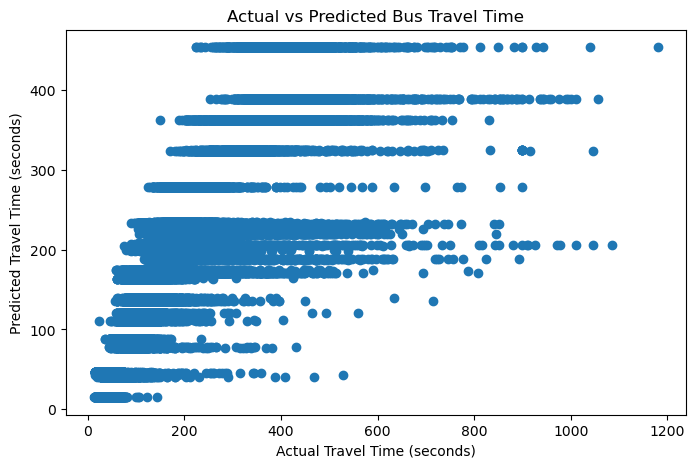

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Travel Time (seconds)")
plt.ylabel("Predicted Travel Time (seconds)")
plt.title("Actual vs Predicted Bus Travel Time")

plt.show()

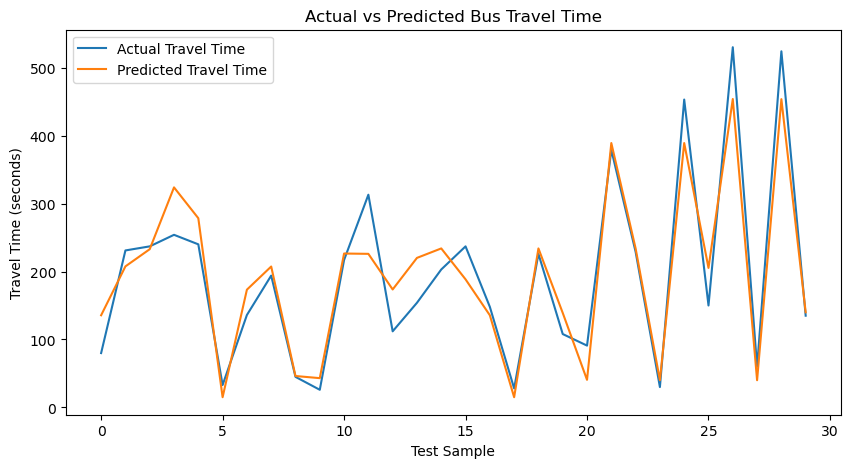

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:30], label="Actual Travel Time")
plt.plot(y_pred[:30], label="Predicted Travel Time")

plt.xlabel("Test Sample")
plt.ylabel("Travel Time (seconds)")
plt.title("Actual vs Predicted Bus Travel Time")
plt.legend()
plt.show()

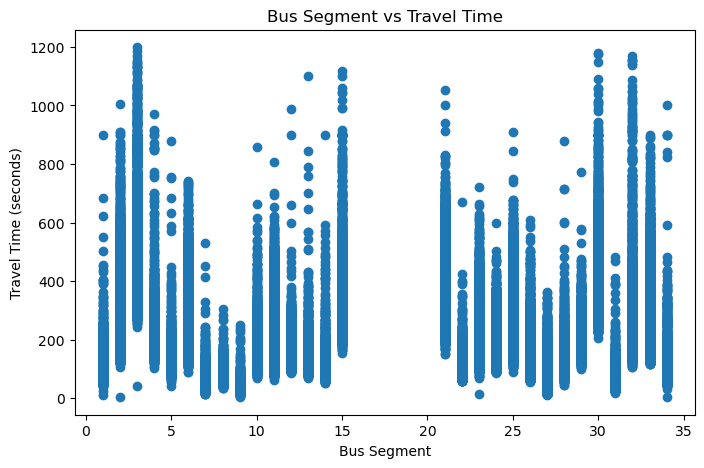

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(data['segment'], data['run_time_in_seconds'])

plt.xlabel("Bus Segment")
plt.ylabel("Travel Time (seconds)")
plt.title("Bus Segment vs Travel Time")
plt.show()

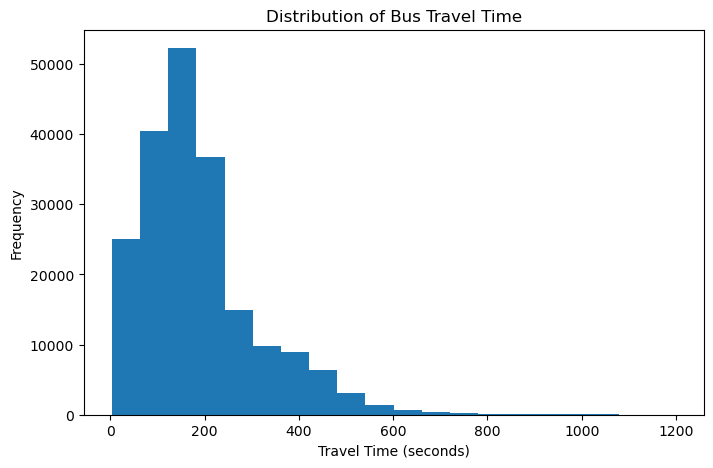

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(data['run_time_in_seconds'], bins=20)

plt.xlabel("Travel Time (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Bus Travel Time")
plt.show()

# Predict Travel Time for a New Bus Journey

In [17]:
new_data = pd.DataFrame({
    'segment': [10],
    'direction': [1],
    'length': [1.5]
})

new_prediction = model.predict(new_data)

print("Predicted Travel Time:", new_prediction[0], "seconds")

Predicted Travel Time: 249.95340528590373 seconds
